In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['figure.figsize'] = (10, 6)

pipeline = pd.read_csv('data/sales_pipeline.csv')
accounts = pd.read_csv('data/accounts.csv')
products = pd.read_csv('data/products.csv')
teams = pd.read_csv('data/sales_teams.csv')

In [3]:
def inspect_data(df, name):
    print(f"--- {name.upper()} ---")
    print(f"Shape: {df.shape}")
    missing = df.isnull().sum()
    missing_cols = missing[missing > 0]
    if not missing_cols.empty:
        print(f"Missing values:\n{missing_cols}")
    else:
        print("Missing values: None")
    print(f"Duplicates: {df.duplicated().sum()}\n")

inspect_data(pipeline, "Sales Pipeline")
inspect_data(accounts, "Accounts")
inspect_data(products, "Products")
inspect_data(teams, "Sales Teams")

--- SALES PIPELINE ---
Shape: (8800, 8)
Missing values:
account        1425
engage_date     500
close_date     2089
close_value    2089
dtype: int64
Duplicates: 0

--- ACCOUNTS ---
Shape: (85, 7)
Missing values:
subsidiary_of    70
dtype: int64
Duplicates: 0

--- PRODUCTS ---
Shape: (7, 3)
Missing values: None
Duplicates: 0

--- SALES TEAMS ---
Shape: (35, 3)
Missing values: None
Duplicates: 0



In [4]:
pipeline['engage_date'] = pd.to_datetime(pipeline['engage_date'])
pipeline['close_date'] = pd.to_datetime(pipeline['close_date'])

pipeline['sales_cycle_days'] = (pipeline['close_date'] - pipeline['engage_date']).dt.days

df = pipeline.merge(accounts, on='account', how='left')
df = df.merge(products, on='product', how='left')
df = df.merge(teams, on='sales_agent', how='left')

print("Master Data Shape:", df.shape)
display(df.head())

Master Data Shape: (8800, 19)


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,sales_cycle_days,sector,year_established,revenue,employees,office_location,subsidiary_of,series,sales_price,manager,regional_office
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,132.0,retail,2001.0,718.62,2448.0,United States,NaN,GTX,1096.0,Dustin Brinkmann,Central
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,137.0,medical,2002.0,3178.24,4540.0,United States,NaN,NaN,NaN,Melvin Marxen,Central
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,133.0,retail,2001.0,718.62,2448.0,United States,NaN,MG,55.0,Melvin Marxen,Central
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,135.0,software,1998.0,2714.90,2641.0,United States,Acme Corporation,GTX,550.0,Dustin Brinkmann,Central
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,128.0,services,1982.0,792.46,1299.0,United States,NaN,GTX,550.0,Summer Sewald,West


C:\Users\Vũ Hoàng Tùng\AppData\Local\Temp\ipykernel_19036\613947833.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=stage_counts.index, y=stage_counts.values, palette='viridis')


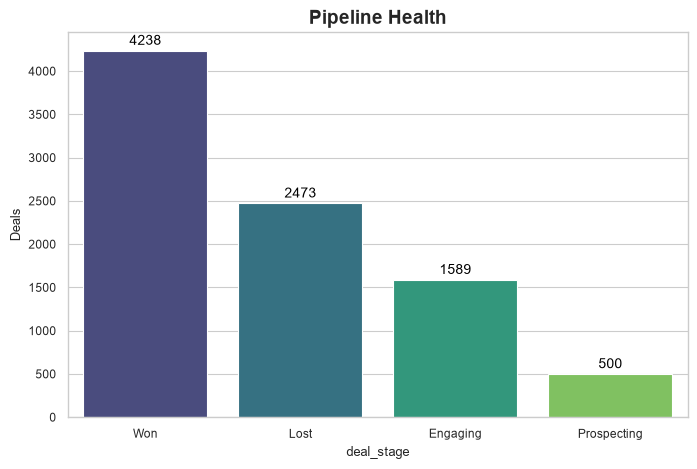

Overall Win Rate: 63.15%


In [5]:
stage_counts = df['deal_stage'].value_counts()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=stage_counts.index, y=stage_counts.values, palette='viridis')
plt.title('Pipeline Health', fontsize=14, fontweight='bold')
plt.ylabel('Deals')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 2),
                textcoords='offset points')
plt.show()

closed_deals = df[df['deal_stage'].isin(['Won', 'Lost'])]
win_rate = len(closed_deals[closed_deals['deal_stage'] == 'Won']) / len(closed_deals)
print(f"Overall Win Rate: {win_rate:.2%}")

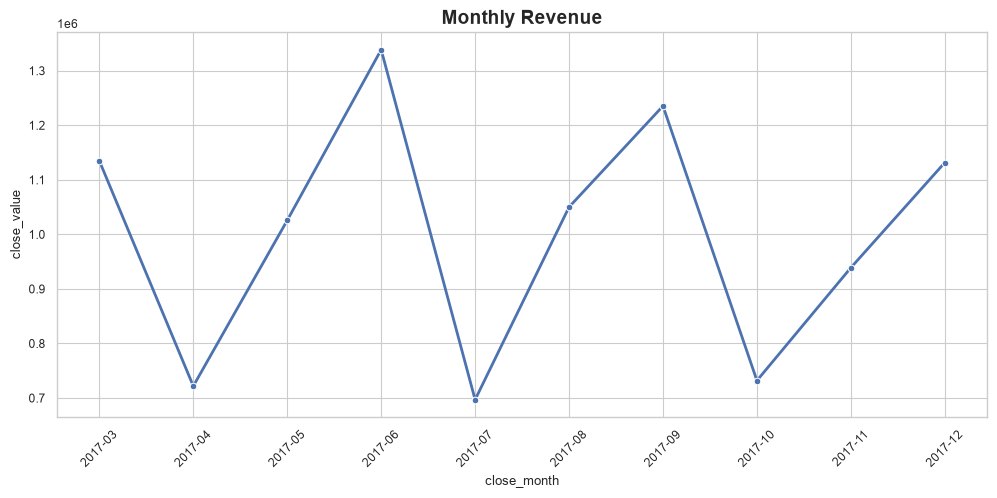

In [6]:
won_df = df[df['deal_stage'] == 'Won'].copy()

won_df['close_month'] = won_df['close_date'].dt.to_period('M').astype(str)
monthly_revenue = won_df.groupby('close_month')['close_value'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_revenue, x='close_month', y='close_value', marker='o', color='b', linewidth=2)
plt.title('Monthly Revenue', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

In [7]:
agent_perf = won_df.groupby(['manager', 'sales_agent']).agg(
    total_revenue=('close_value', 'sum'),
    deals_won=('opportunity_id', 'count'),
    avg_sales_cycle=('sales_cycle_days', 'mean')
).reset_index().sort_values(by='total_revenue', ascending=False)

display(agent_perf.head(10).style.format({
    'total_revenue': '${:,.0f}',
    'avg_sales_cycle': '{:.1f}'
}))

manager_perf = agent_perf.groupby('manager').agg(
    team_total_revenue=('total_revenue', 'sum'),
    total_deals_won=('deals_won', 'sum')
).sort_values(by='team_total_revenue', ascending=False)

display(manager_perf.style.format({'team_total_revenue': '${:,.0f}'}))

,manager,sales_agent,total_revenue,deals_won,avg_sales_cycle
15,Melvin Marxen,Darcel Schlecht,"$1,153,214",349,49.4
9,Celia Rouche,Vicki Laflamme,"$478,396",221,53.6
27,Summer Sewald,Kary Hendrixson,"$454,298",209,53.0
21,Rocco Neubert,Cassey Cress,"$450,489",163,48.8
23,Rocco Neubert,Donn Cantrell,"$445,860",158,53.3
24,Rocco Neubert,Reed Clapper,"$438,336",155,49.0
29,Summer Sewald,Zane Levy,"$430,068",161,46.9
0,Cara Losch,Corliss Cosme,"$421,036",150,51.1
25,Summer Sewald,James Ascencio,"$413,533",135,53.4
22,Rocco Neubert,Daniell Hammack,"$364,229",114,46.6


,team_total_revenue,total_deals_won
manager,,
Melvin Marxen,"$2,251,930",882
Summer Sewald,"$1,964,750",828
Rocco Neubert,"$1,960,545",691
Celia Rouche,"$1,603,897",610
Cara Losch,"$1,130,049",480
Dustin Brinkmann,"$1,094,363",747


In [8]:
product_perf = won_df.groupby('product').agg(
    total_revenue=('close_value', 'sum'),
    deals_won=('opportunity_id', 'count'),
    avg_close_value=('close_value', 'mean')
).reset_index().sort_values(by='total_revenue', ascending=False)

product_closed = closed_deals.groupby('product').agg(total_closed=('opportunity_id', 'count')).reset_index()
product_perf = product_perf.merge(product_closed, on='product')
product_perf['win_rate'] = product_perf['deals_won'] / product_perf['total_closed']

display(product_perf[['product', 'total_revenue', 'deals_won', 'win_rate', 'avg_close_value']].style.format({
    'total_revenue': '${:,.0f}',
    'avg_close_value': '${:,.0f}',
    'win_rate': '{:.2%}'
}))

,product,total_revenue,deals_won,win_rate,avg_close_value
0,GTXPro,"$3,510,578",729,63.56%,"$4,816"
1,GTX Plus Pro,"$2,629,651",479,64.30%,"$5,490"
2,MG Advanced,"$2,216,387",654,60.33%,"$3,389"
3,GTX Plus Basic,"$705,275",653,62.13%,"$1,080"
4,GTX Basic,"$499,263",915,63.72%,$546
5,GTK 500,"$400,612",15,60.00%,"$26,707"
6,MG Special,"$43,768",793,64.84%,$55


In [2]:
pipeline['engage_date'] = pd.to_datetime(pipeline['engage_date'])
pipeline['close_date'] = pd.to_datetime(pipeline['close_date'])

pipeline['sales_cycle_days'] = (pipeline['close_date'] - pipeline['engage_date']).dt.days

df = pipeline.merge(accounts, on='account', how='left')
df = df.merge(products, on='product', how='left')
df = df.merge(teams, on='sales_agent', how='left')

df['deal_stage'] = pd.Categorical(
    df['deal_stage'], 
    categories=['Prospecting', 'Engaging', 'Won', 'Lost'], 
    ordered=True
)
df = df.sort_values(by=['engage_date', 'deal_stage'], ascending=[False, True]).reset_index(drop=True)

print("Master Data Shape:", df.shape)
display(df.head())

Master Data Shape: (8800, 19)


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,sales_cycle_days,sector,year_established,revenue,employees,office_location,subsidiary_of,series,sales_price,manager,regional_office
0,YJTQSZ9D,Gladys Colclough,GTX Plus Basic,Inity,Won,2017-12-27,2017-12-30,1052.0,3.0,marketing,1986.0,2403.58,8801.0,United States,NaN,GTX,1096.0,Melvin Marxen,Central
1,RB8GDYFY,Gladys Colclough,MG Special,Betatech,Won,2017-12-27,2017-12-29,67.0,2.0,medical,1986.0,647.18,1185.0,Kenya,NaN,MG,55.0,Melvin Marxen,Central
2,6WCNNK5J,Maureen Marcano,GTXPro,Hottechi,Won,2017-12-26,2017-12-29,4433.0,3.0,technolgy,1997.0,8170.38,16499.0,Korea,NaN,NaN,NaN,Summer Sewald,West
3,1YBATFAY,James Ascencio,GTX Basic,Singletechno,Won,2017-12-24,2017-12-26,538.0,2.0,retail,1996.0,2214.94,5374.0,United States,NaN,GTX,550.0,Summer Sewald,West
4,2EBLR9N8,Lajuana Vencill,GTX Basic,Conecom,Won,2017-12-24,2017-12-26,622.0,2.0,technolgy,2005.0,1520.66,1806.0,United States,NaN,GTX,550.0,Dustin Brinkmann,Central
